# Analysis 3: ADMET-driven Representation Structure (t-SNE)

Project pretrained molecular representations to 2D via t-SNE and color points
by TDC ADMET property values. Compares the smoothness (regression) and class
separation (binary) across encoders pretrained on different datasets.

**What this complements**
- `02a_analysis_cka.ipynb` quantifies alignment with ADMET labels via CKA.
- This notebook visualizes the *same* embeddings to show whether the space
  organizes molecules along pharmacokinetically/toxicologically meaningful axes.

**Tasks visualized** (subset chosen for size and biological breadth):
- Continuous: `solubility_aqsoldb` (~10K), `lipophilicity_astrazeneca` (~4K), `ld50_zhu` (~7K)
- Binary:     `herg` (~648), `bbb_martins` (~2K)

**Prerequisites**: Run `python scripts/cka_analysis.py` first — it caches
`embeddings_<ckpt>.pt` files under `results/cka_analysis/` that this notebook reuses.

In [52]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 120})

EMB_DIR = Path("../results/cka_analysis")
OUT_DIR = Path("../results/tsne_admet")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
MAX_POINTS = 5000  # cap per (checkpoint, task) for tractable t-SNE

## 1. Load TDC ADMET labels for the visualization subset

In [53]:
from tdc.benchmark_group import admet_group

VIZ_TASKS = {
    # task_name: ('regression' | 'classification', display_name, units_or_label)
    "solubility_aqsoldb":         ("regression",     "Aqueous Solubility",      "log mol/L"),
    "lipophilicity_astrazeneca":  ("regression",     "Lipophilicity",           "logD"),
    "ld50_zhu":                   ("regression",     "Acute Toxicity (LD50)",   "-log(mol/kg)"),
    "herg":                       ("classification", "hERG Blockade",           "class"),
    "bbb_martins":                ("classification", "Blood-Brain Barrier",     "class"),
}

group = admet_group(path="../data/tdc_admet_cache")

task_data = {}
for task in VIZ_TASKS:
    bench = group.get(task)
    df_t = pd.concat([bench["train_val"], bench["test"]], ignore_index=True)
    df_t = df_t[~df_t["Y"].isna()].reset_index(drop=True)
    task_data[task] = {
        "smiles": df_t["Drug"].tolist(),
        "y":      df_t["Y"].values.astype(np.float32),
    }
    print(f"  {task}: {len(df_t)} molecules")

Found local copy...


  solubility_aqsoldb: 9982 molecules
  lipophilicity_astrazeneca: 4200 molecules
  ld50_zhu: 7385 molecules
  herg: 655 molecules
  bbb_martins: 2030 molecules


## 2. Load cached embeddings

`scripts/cka_analysis.py` saves `embeddings_<ckpt>.pt` with keys `gnn`, `graph`, `smiles`.
We use the **graph-level** embedding (post pooling MLP) for visualization.

In [54]:
EMB_TYPE = "graph"  # or 'gnn'

# Restrict the cached PairMixer ckpts to the six used in the report.
KEEP_CKPTS = [
    "largemix",
    "toymix",
    "toymix_all",
    "toymix_bbbc047",
    "toymix_lpm24_litopenai",
    "toymix_dti_esmcv2",
]

ckpt_files = sorted(EMB_DIR.glob("embeddings_*.pt"))
checkpoints = {}
for f in ckpt_files:
    name = f.stem.replace("embeddings_", "")
    if name == "data":
        continue  # raw-feature baseline lacks 'graph'/'gnn' keys
    if name not in KEEP_CKPTS:
        continue
    blob = torch.load(f, map_location="cpu", weights_only=False)
    if EMB_TYPE not in blob:
        continue
    smiles = blob["smiles"]
    emb = blob[EMB_TYPE].float().numpy()
    checkpoints[name] = {
        "emb":    emb,
        "smi2i": {s: i for i, s in enumerate(smiles)},
    }
    print(f"  {name}: {emb.shape}")

# --- Foundation-model baselines (MiniMol, MolE, KPGT) ---
# Extracted via the downstream encoder adapters and cached under OUT_DIR.
# KPGT runs CPU-only via subprocess; MolE / MiniMol use their bundled packages.
BASELINE_NAMES = ["minimol", "mole", "kpgt"]

import sys as _sys
_REPO_ROOT = str(Path("..").resolve())
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)

try:
    from downstream.model import load_encoder
except Exception as exc:
    print(f"  skip baselines: load_encoder import failed ({exc})")
    load_encoder = None

if load_encoder is not None:
    union_smiles = sorted({s for d in task_data.values() for s in d["smiles"]})
    print(f"\n  union SMILES across {len(VIZ_TASKS)} viz tasks: {len(union_smiles)}")
    for name in BASELINE_NAMES:
        cache_path = OUT_DIR / f"baseline_{name}.pt"
        try:
            enc = load_encoder(name)
        except Exception as exc:
            print(f"  skip {name}: load_encoder failed ({type(exc).__name__}: {exc})")
            continue
        try:
            emb, mask = enc.extract_cached(union_smiles, cache_path=cache_path)
        except Exception as exc:
            print(f"  skip {name}: extract failed ({type(exc).__name__}: {exc})")
            continue
        kept = [s for s, m in zip(union_smiles, mask) if m]
        checkpoints[name] = {
            "emb":   emb,
            "smi2i": {s: i for i, s in enumerate(kept)},
        }
        print(f"  {name}: {emb.shape}")

# Display order: PairMixer ckpts first, then baselines.
CKPT_NAMES = ([n for n in KEEP_CKPTS if n in checkpoints]
              + [n for n in BASELINE_NAMES if n in checkpoints])
missing_pm = [n for n in KEEP_CKPTS if n not in checkpoints]
if missing_pm:
    print(f"\n  missing PairMixer ckpts: {missing_pm}")
print(f"\nLoaded {len(CKPT_NAMES)} encoders: {CKPT_NAMES}")


  largemix: (46201, 1024)
  toymix: (46201, 512)
  toymix_all: (46201, 512)
  toymix_bbbc047: (46201, 512)
  toymix_dti_esmcv2: (46201, 512)
  toymix_lpm24_litopenai: (46201, 512)

  union SMILES across 5 viz tasks: 21161
  minimol: (21161, 512)
  mole: (21161, 1000)
  [kpgt_base] WARN: 2 SMILES un-embeddable; rows dropped.
  kpgt: (21159, 2304)

Loaded 9 encoders: ['largemix', 'toymix', 'toymix_all', 'toymix_bbbc047', 'toymix_lpm24_litopenai', 'toymix_dti_esmcv2', 'minimol', 'mole', 'kpgt']


## 3. Run t-SNE per (checkpoint, task)

For each task we keep only the molecules present in the cached embedding set,
subsample to `MAX_POINTS`, then run t-SNE on the standardized embeddings.
Results are cached on disk so reruns of plotting cells are fast.

In [55]:
def project_tsne(emb: np.ndarray, perplexity: float = 30.0) -> np.ndarray:
    n = emb.shape[0]
    perp = max(5.0, min(perplexity, (n - 1) / 3.0))
    X = StandardScaler().fit_transform(emb)
    tsne = TSNE(
        n_components=2, perplexity=perp, learning_rate="auto",
        init="pca", random_state=RANDOM_STATE, n_iter=1000,
    )
    return tsne.fit_transform(X)


tsne_cache = {}  # (ckpt, task) -> dict(coords, y, idx)

for ckpt in CKPT_NAMES:
    smi2i = checkpoints[ckpt]["smi2i"]
    emb_full = checkpoints[ckpt]["emb"]
    for task, (kind, *_) in VIZ_TASKS.items():
        cache_path = OUT_DIR / f"tsne_{ckpt}_{task}.npz"
        if cache_path.exists():
            blob = np.load(cache_path)
            tsne_cache[(ckpt, task)] = {
                "coords": blob["coords"], "y": blob["y"],
            }
            continue

        smi_list = task_data[task]["smiles"]
        y_list   = task_data[task]["y"]
        idx, y_keep = [], []
        for s, y in zip(smi_list, y_list):
            if s in smi2i:
                idx.append(smi2i[s])
                y_keep.append(y)
        if len(idx) < 30:
            print(f"  skip {ckpt}/{task}: only {len(idx)} matched")
            continue

        idx = np.asarray(idx); y_keep = np.asarray(y_keep, dtype=np.float32)
        if len(idx) > MAX_POINTS:
            rng = np.random.default_rng(RANDOM_STATE)
            sel = rng.choice(len(idx), size=MAX_POINTS, replace=False)
            idx, y_keep = idx[sel], y_keep[sel]

        coords = project_tsne(emb_full[idx])
        np.savez(cache_path, coords=coords, y=y_keep)
        tsne_cache[(ckpt, task)] = {"coords": coords, "y": y_keep}
        print(f"  {ckpt}/{task}: {coords.shape[0]} pts -> {cache_path.name}")

print(f"\nCached {len(tsne_cache)} (ckpt, task) projections")


Cached 45 (ckpt, task) projections


## 4. Comparison grid: rows = tasks, cols = checkpoints

A smooth color gradient (regression) or clean separation (binary) indicates the
encoder has captured ADMET-relevant structure beyond pure chemical similarity.

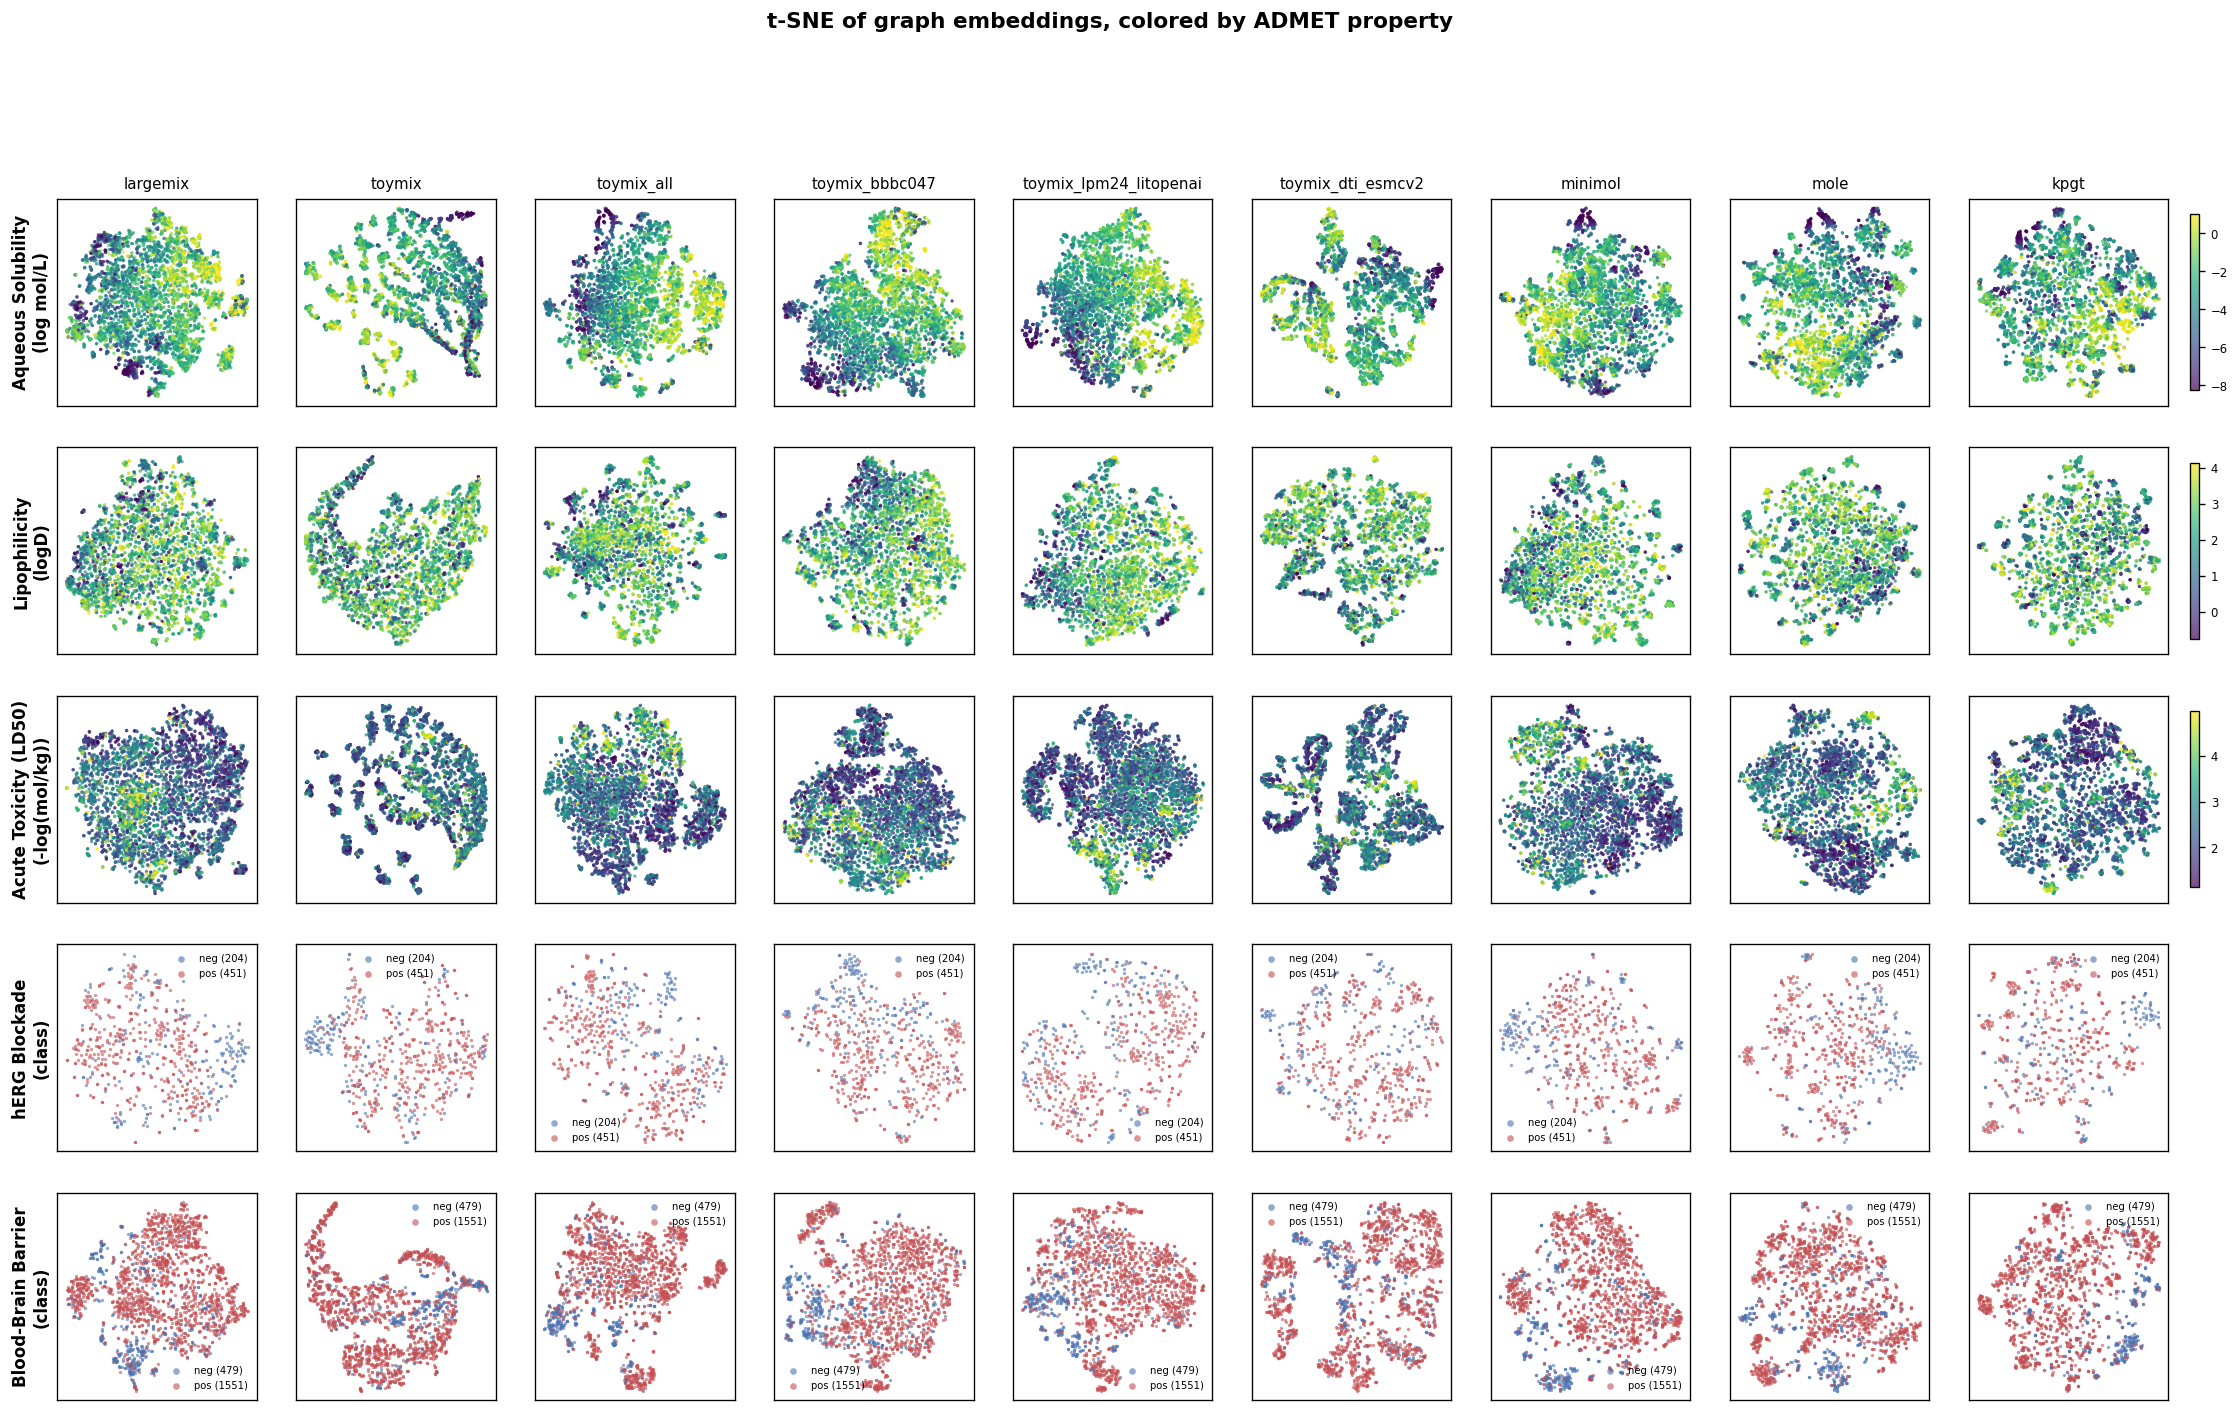

In [ ]:
def _plot_one(ax, coords, y, kind, title, cmap_reg="viridis", vmin=None, vmax=None):
    if coords is None:
        ax.set_axis_off()
        ax.set_title(title, fontsize=9, color="#999")
        return None
    if kind == "regression":
        if vmin is None or vmax is None:
            vmin, vmax = np.quantile(y, [0.02, 0.98])
        sc = ax.scatter(
            coords[:, 0], coords[:, 1], c=y, cmap=cmap_reg,
            vmin=vmin, vmax=vmax, s=4, alpha=0.7, linewidth=0,
        )
    else:
        y_int = y.astype(int)
        for cls, c, lbl in [(0, "#4C72B0", "neg"), (1, "#C44E52", "pos")]:
            m = y_int == cls
            ax.scatter(
                coords[m, 0], coords[m, 1], c=c, s=4, alpha=0.6,
                linewidth=0, label=f"{lbl} ({m.sum()})",
            )
        ax.legend(fontsize=6, markerscale=2, loc="best", frameon=False)
        sc = None
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=9)
    return sc


n_rows, n_cols = len(VIZ_TASKS), len(CKPT_NAMES)
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(2.6 * n_cols, 2.6 * n_rows), squeeze=False,
)

for r, (task, (kind, disp, units)) in enumerate(VIZ_TASKS.items()):
    last_sc = None
    # Uniform colorbar per task (regression only): pool y across the ckpts in this
    # row and take 2nd / 98th percentiles so every panel uses the same scale.
    task_vmin = task_vmax = None
    if kind == "regression":
        ys = [tsne_cache[(c, task)]["y"] for c in CKPT_NAMES if (c, task) in tsne_cache]
        if ys:
            pooled = np.concatenate(ys)
            task_vmin, task_vmax = np.quantile(pooled, [0.02, 0.98])
    for c, ckpt in enumerate(CKPT_NAMES):
        ax = axes[r, c]
        entry = tsne_cache.get((ckpt, task))
        title = ckpt if r == 0 else ""
        if entry is None:
            _plot_one(ax, None, None, kind, title)
            continue
        sc = _plot_one(ax, entry["coords"], entry["y"], kind, title,
                       vmin=task_vmin, vmax=task_vmax)
        if sc is not None:
            last_sc = sc
        if c == 0:
            ax.set_ylabel(f"{disp}\n({units})", fontsize=10, fontweight="bold")
    if kind == "regression" and last_sc is not None:
        cbar = fig.colorbar(
            last_sc, ax=axes[r, :].tolist(), shrink=0.85, pad=0.01, fraction=0.02,
        )
        cbar.ax.tick_params(labelsize=7)
    elif kind == "classification":
        # Phantom colorbar: same layout footprint as regression rows, fully
        # transparent so the grid columns stay aligned.
        import matplotlib.cm as _cm
        _sm = _cm.ScalarMappable(cmap="viridis")
        _sm.set_array([])
        _cbar = fig.colorbar(
            _sm, ax=axes[r, :].tolist(), shrink=0.85, pad=0.01, fraction=0.02,
        )
        _cbar.ax.set_visible(False)

fig.suptitle(
    f"t-SNE of {EMB_TYPE} embeddings, colored by ADMET property",
    fontsize=13, fontweight="bold", y=1.0,
)
fig.savefig(OUT_DIR / f"tsne_grid_{EMB_TYPE}.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Quantitative companion: 2D neighborhood smoothness

For each (checkpoint, task) we compute a simple smoothness score on the t-SNE
embedding: average label-correlation with k-nearest neighbors in 2D space.

- Regression: mean Pearson correlation of $y_i$ with its kNN labels.
- Binary: mean fraction of kNNs that share the class of $y_i$ (above majority baseline).

Higher = smoother color organization in the t-SNE map. This is a sanity-check
indicator and not a substitute for the downstream evaluation.

In [57]:
from sklearn.neighbors import NearestNeighbors

K = 10
rows = []
for (ckpt, task), entry in tsne_cache.items():
    coords, y = entry["coords"], entry["y"]
    kind = VIZ_TASKS[task][0]
    nn = NearestNeighbors(n_neighbors=K + 1).fit(coords)
    _, idx = nn.kneighbors(coords)
    nbr_idx = idx[:, 1:]  # drop self

    if kind == "regression":
        nbr_y = y[nbr_idx]
        # Pearson r between each label and the mean label of its t-SNE kNN.
        # High r = neighborhoods are predictive of the central label (smooth field).
        nbr_mean_y = nbr_y.mean(axis=1)
        if y.std() == 0 or np.isclose(nbr_mean_y.std(), 0):
            score = 0.0
        else:
            score = float(np.corrcoef(y, nbr_mean_y)[0, 1])
        baseline = 0.0
    else:
        y_int = y.astype(int)
        nbr_y = y_int[nbr_idx]
        agree = (nbr_y == y_int[:, None]).mean(axis=1)
        score = float(agree.mean())
        baseline = float(max(np.mean(y_int == 0), np.mean(y_int == 1)))
    rows.append({
        "checkpoint": ckpt, "task": task, "kind": kind,
        "smoothness": score, "baseline": baseline, "n": len(y),
    })

smooth_df = pd.DataFrame(rows)
smooth_df.to_csv(OUT_DIR / f"tsne_smoothness_{EMB_TYPE}.csv", index=False)

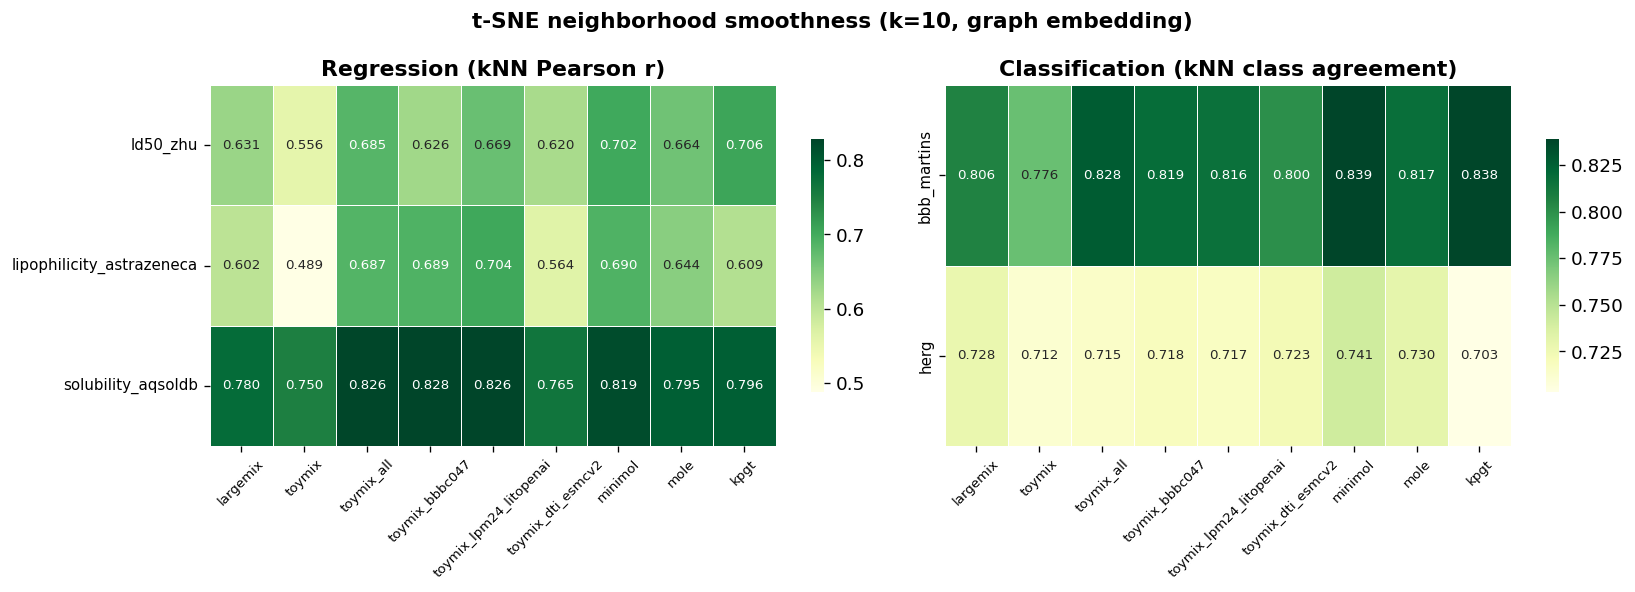

In [58]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, kind in zip(axes, ["regression", "classification"]):
    sub = smooth_df[smooth_df["kind"] == kind]
    if sub.empty:
        ax.set_axis_off()
        continue
    pivot = sub.pivot(index="task", columns="checkpoint", values="smoothness")
    pivot = pivot.reindex(columns=CKPT_NAMES)
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f", cmap="YlGn",
        linewidths=0.5, linecolor="white", annot_kws={"fontsize": 8},
        cbar_kws={"shrink": 0.7},
    )
    label = "kNN Pearson r" if kind == "regression" else "kNN class agreement"
    ax.set_title(f"{kind.title()} ({label})", fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle(
    f"t-SNE neighborhood smoothness (k={K}, {EMB_TYPE} embedding)",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()
fig.savefig(OUT_DIR / f"tsne_smoothness_{EMB_TYPE}.png", dpi=150, bbox_inches="tight")
plt.show()